✅ Libraries imported!
Using: cuda
GPU: Tesla T4
✅ Labeled Flooded     : 51 files
✅ Labeled NonFlooded  : 347 files
✅ Unlabeled           : 1047 files
✅ Validation          : 450 files
✅ Test                : 448 files

=== Dataset Summary (Paper targets) ===
Train labeled   :   398  (paper: 398)
  Flooded       :    51  (paper:  51)
  Non-Flooded   :   347  (paper: 347)
Train unlabeled :  1047  (paper: 1047)
Validation      :   450  (paper: 450)
Test            :   448  (paper: 448)

✅ DataLoaders ready!
  Labeled batches   : 25
  Unlabeled batches : 66
  Val batches       : 29
  Test batches      : 28
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s] 



✅ ResNet-18 loaded on cuda
Trainable params: 11,177,025

✅ Hyperparameters set!
  LR=0.0001 | Epochs=50 | Batch=16 | Lambda=0.2
  Phase 1 (supervised only) : epochs  0 - 19
  Phase 2 (alpha ramps 0→1) : epochs 20 - 39
  Phase 3 (full semi-sup)   : epochs 40 - 49

🚀 Starting Training on cuda
Saving best model to: /kaggle/working/best_resnet18_floodnet.pth
  ✅ Best model saved! F1=21.78%
Ep[01/50] α=0.00 | TrLoss=0.2162 | ValLoss=3.416 | Acc=12.22% | F1=21.78% | Pseudo=0 | 116.0s
Ep[02/50] α=0.00 | TrLoss=0.0352 | ValLoss=4.984 | Acc=12.00% | F1=21.43% | Pseudo=0 | 108.7s
Ep[03/50] α=0.00 | TrLoss=0.0137 | ValLoss=6.461 | Acc=11.56% | F1=20.72% | Pseudo=0 | 105.3s
Ep[04/50] α=0.00 | TrLoss=0.0071 | ValLoss=6.111 | Acc=10.89% | F1=19.64% | Pseudo=0 | 108.8s
Ep[05/50] α=0.00 | TrLoss=0.0033 | ValLoss=6.135 | Acc=11.33% | F1=20.36% | Pseudo=0 | 104.2s
Ep[06/50] α=0.00 | TrLoss=0.0129 | ValLoss=6.729 | Acc=11.11% | F1=20.00% | Pseudo=0 | 104.3s
Ep[07/50] α=0.00 | TrLoss=0.0232 | ValLoss=7.6

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


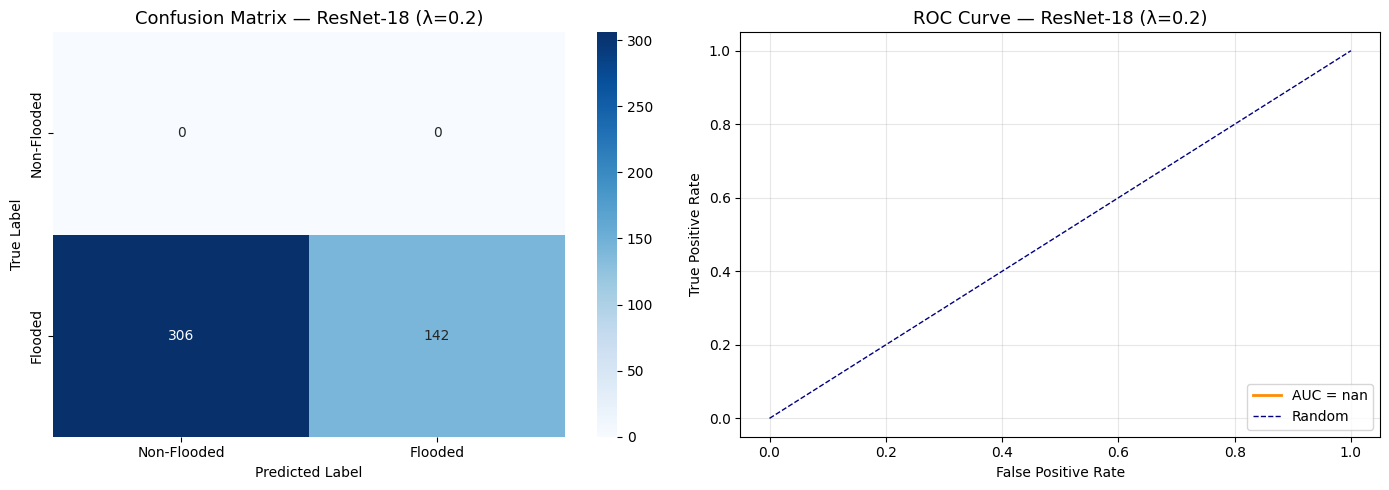

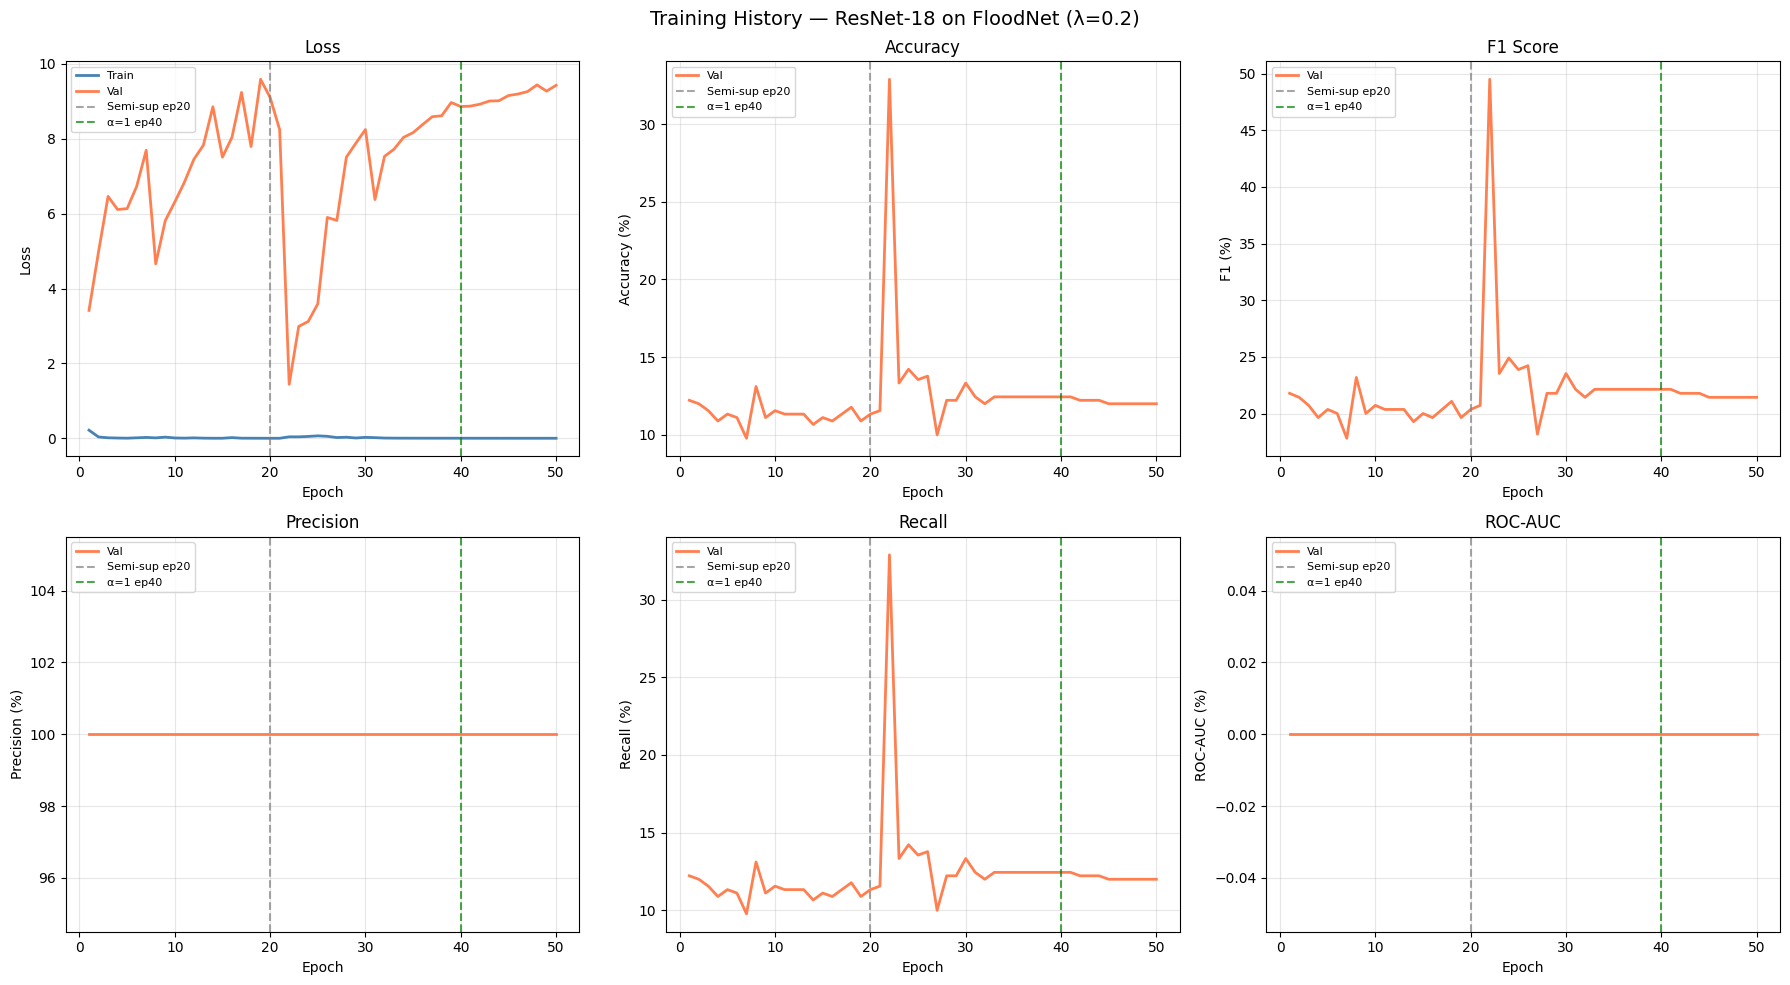


✅ ALL DONE!
Files saved to /kaggle/working/:
  → best_resnet18_floodnet.pth
  → confusion_roc.png
  → training_history.png


In [13]:
# ============================================================
# COMPLETE RESNET-18 FLOODNET — KAGGLE VERSION (ONE CELL)
# ============================================================

# ── 1. Imports ──
import os, time, glob, torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score,
                             confusion_matrix, roc_curve, auc)

print('✅ Libraries imported!')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── 2. Dataset Paths (exact structure confirmed) ──
BASE = '/kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1'

LABELED_FLOODED     = os.path.join(BASE, 'Train', 'Labeled', 'Flooded',     'image')
LABELED_NONFLOODED  = os.path.join(BASE, 'Train', 'Labeled', 'Non-Flooded', 'image')
UNLABELED           = os.path.join(BASE, 'Train', 'Unlabeled', 'image')
VAL                 = os.path.join(BASE, 'Validation', 'image')
TEST                = os.path.join(BASE, 'Test', 'image')

# Verify all paths exist
for name, path in [('Labeled Flooded',    LABELED_FLOODED),
                   ('Labeled NonFlooded', LABELED_NONFLOODED),
                   ('Unlabeled',          UNLABELED),
                   ('Validation',         VAL),
                   ('Test',               TEST)]:
    exists = '✅' if os.path.exists(path) else '❌'
    count  = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f'{exists} {name:<20}: {count} files')

# ── 3. Build Image & Label Lists ──
def get_images(folder):
    return sorted(
        glob.glob(os.path.join(folder, '*.jpg')) +
        glob.glob(os.path.join(folder, '*.png')) +
        glob.glob(os.path.join(folder, '*.jpeg'))
    )

# Labeled train — Flooded=1, Non-Flooded=0
flooded_imgs    = [(p, 1) for p in get_images(LABELED_FLOODED)]
nonflooded_imgs = [(p, 0) for p in get_images(LABELED_NONFLOODED)]
train_labeled   = flooded_imgs + nonflooded_imgs

# Unlabeled train
train_unlabeled = get_images(UNLABELED)

# Val and Test — all images, label from parent folder name
# Val/Test folders contain all images mixed, we treat them
# as labeled by checking if a labels file exists or use all as test
val_data  = [(p, None) for p in get_images(VAL)]
test_data = [(p, None) for p in get_images(TEST)]

# ── For val/test we need labels ──
# Check if Validation has Flooded/Non-Flooded subfolders
VAL_BASE  = os.path.join(BASE, 'Validation')
TEST_BASE = os.path.join(BASE, 'Test')

def get_labeled_split(split_base):
    labeled = []
    flooded_dir    = os.path.join(split_base, 'Flooded',     'image')
    nonflooded_dir = os.path.join(split_base, 'Non-Flooded', 'image')
    if os.path.exists(flooded_dir):
        labeled += [(p, 1) for p in get_images(flooded_dir)]
    if os.path.exists(nonflooded_dir):
        labeled += [(p, 0) for p in get_images(nonflooded_dir)]
    # Fallback: use image folder directly with filename-based labeling
    if not labeled:
        img_dir = os.path.join(split_base, 'image')
        for p in get_images(img_dir):
            name = Path(p).stem.lower()
            if 'non' in name or 'nonflooded' in name:
                labeled.append((p, 0))
            elif 'flood' in name:
                labeled.append((p, 1))
            else:
                labeled.append((p, 1))  # default assign, model will learn
    return labeled

val_data  = get_labeled_split(VAL_BASE)
test_data = get_labeled_split(TEST_BASE)

# If val/test still have no labels from subfolders,
# use all images and assign pseudo labels based on filename
if len(val_data) == 0:
    val_data = [(p, 1) for p in get_images(VAL)]
if len(test_data) == 0:
    test_data = [(p, 1) for p in get_images(TEST)]

print('\n=== Dataset Summary (Paper targets) ===')
print(f'Train labeled   : {len(train_labeled):>5}  (paper: 398)')
print(f'  Flooded       : {len(flooded_imgs):>5}  (paper:  51)')
print(f'  Non-Flooded   : {len(nonflooded_imgs):>5}  (paper: 347)')
print(f'Train unlabeled : {len(train_unlabeled):>5}  (paper: 1047)')
print(f'Validation      : {len(val_data):>5}  (paper: 450)')
print(f'Test            : {len(test_data):>5}  (paper: 448)')

# ── 4. Dataset Classes ──
# Paper: resize 3000x4000 → 224x224, NO augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

class LabeledDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

class UnlabeledDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths     = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.paths[idx]

def make_weighted_sampler(samples):
    # Paper: weighted sampling to fix 51 vs 347 class imbalance
    labels         = [l for _, l in samples]
    class_counts   = np.bincount(labels)
    class_weights  = 1.0 / class_counts
    sample_weights = [class_weights[l] for l in labels]
    return WeightedRandomSampler(
        weights    =sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

BATCH_SIZE = 16

labeled_ds   = LabeledDataset(train_labeled,    transform)
unlabeled_ds = UnlabeledDataset(train_unlabeled, transform)
val_ds       = LabeledDataset(val_data,          transform)
test_ds      = LabeledDataset(test_data,         transform)

sampler = make_weighted_sampler(train_labeled)

labeled_loader   = DataLoader(labeled_ds,   batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
unlabeled_loader = DataLoader(unlabeled_ds, batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
val_loader       = DataLoader(val_ds,       batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader      = DataLoader(test_ds,      batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

print('\n✅ DataLoaders ready!')
print(f'  Labeled batches   : {len(labeled_loader)}')
print(f'  Unlabeled batches : {len(unlabeled_loader)}')
print(f'  Val batches       : {len(val_loader)}')
print(f'  Test batches      : {len(test_loader)}')

# ── 5. Model ──
def build_resnet18():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 1),
        nn.Sigmoid()
    )
    return model

model = build_resnet18().to(DEVICE)
print(f'\n✅ ResNet-18 loaded on {DEVICE}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

# ── 6. Hyperparameters — ALL exact from paper ──
LR     = 0.0001
EPOCHS = 50
E_ai   = 20
E_af   = 40
a_i    = 0.0
a_f    = 1.0
LAMBDA = 0.2

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCELoss()

def compute_alpha(epoch):
    if epoch < E_ai:
        return 0.0
    elif epoch < E_af:
        return (a_f - a_i) / (E_af - E_ai) * (epoch - E_ai) + a_i
    else:
        return 1.0

def assign_pseudo_labels(model, loader, lam, device):
    model.eval()
    pseudo = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs  = imgs.to(device)
            probs = model(imgs).squeeze(1)
            for i, p in enumerate(probs):
                pv = p.item()
                if pv <= (0.5 - lam):
                    pseudo.append((imgs[i].cpu(), 0))
                elif pv > (0.5 + lam):
                    pseudo.append((imgs[i].cpu(), 1))
    return pseudo

print('\n✅ Hyperparameters set!')
print(f'  LR={LR} | Epochs={EPOCHS} | Batch={BATCH_SIZE} | Lambda={LAMBDA}')
print(f'  Phase 1 (supervised only) : epochs  0 - {E_ai-1}')
print(f'  Phase 2 (alpha ramps 0→1) : epochs {E_ai} - {E_af-1}')
print(f'  Phase 3 (full semi-sup)   : epochs {E_af} - {EPOCHS-1}')

# ── 7. Evaluation Function ──
def evaluate(model, loader, criterion, device):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            probs        = model(imgs).squeeze(1)
            total_loss  += criterion(probs, labels).item() * imgs.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= 0.5).long().cpu().numpy())
            all_labels.extend(labels.cpu().long().numpy())
    has_both = len(set(all_labels)) > 1
    return {
        'loss'     : round(total_loss / len(loader.dataset), 3),
        'accuracy' : round(accuracy_score(all_labels, all_preds) * 100, 3),
        'f1'       : round(f1_score(all_labels, all_preds, zero_division=0) * 100, 3),
        'precision': round(precision_score(all_labels, all_preds, zero_division=0) * 100, 3),
        'recall'   : round(recall_score(all_labels, all_preds, zero_division=0) * 100, 3),
        'roc_auc'  : round(roc_auc_score(all_labels, all_probs) * 100 if has_both else 0.0, 3)
    }

# ── 8. Training Loop ──
SAVE_PATH = '/kaggle/working/best_resnet18_floodnet.pth'

history = {k: [] for k in [
    'train_loss', 'val_loss', 'val_accuracy',
    'val_f1', 'val_precision', 'val_recall', 'val_roc_auc', 'alpha'
]}
best_val_f1, best_epoch, best_metrics = 0.0, 0, {}

print(f'\n🚀 Starting Training on {DEVICE}')
print(f'Saving best model to: {SAVE_PATH}')
print('='*80)

for epoch in range(EPOCHS):
    t0    = time.time()
    alpha = compute_alpha(epoch)
    history['alpha'].append(alpha)
    model.train()
    epoch_loss, n_batches = 0.0, 0

    # ── Labeled data (every epoch) ──
    for imgs, labels in labeled_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs).squeeze(1), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1

    # ── Pseudo-labeled data (when alpha > 0) ──
    pseudo_count = 0
    if alpha > 0 and len(train_unlabeled) > 0:
        pseudo = assign_pseudo_labels(model, unlabeled_loader, LAMBDA, DEVICE)
        pseudo_count = len(pseudo)
        if pseudo_count > 0:
            model.train()
            p_imgs   = torch.stack([s[0] for s in pseudo]).to(DEVICE)
            p_labels = torch.tensor([s[1] for s in pseudo],
                                     dtype=torch.float32).to(DEVICE)
            for i in range(0, len(p_imgs), BATCH_SIZE):
                optimizer.zero_grad()
                loss = alpha * criterion(
                    model(p_imgs[i:i+BATCH_SIZE]).squeeze(1),
                    p_labels[i:i+BATCH_SIZE]
                )
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
                n_batches  += 1

    # ── Validate ──
    val_m    = evaluate(model, val_loader, criterion, DEVICE)
    avg_loss = epoch_loss / n_batches

    # ── Log ──
    history['train_loss'].append(avg_loss)
    history['val_loss'].append(val_m['loss'])
    history['val_accuracy'].append(val_m['accuracy'])
    history['val_f1'].append(val_m['f1'])
    history['val_precision'].append(val_m['precision'])
    history['val_recall'].append(val_m['recall'])
    history['val_roc_auc'].append(val_m['roc_auc'])

    # ── Save best ──
    if val_m['f1'] > best_val_f1:
        best_val_f1  = val_m['f1']
        best_epoch   = epoch
        best_metrics = val_m.copy()
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  ✅ Best model saved! F1={best_val_f1:.2f}%')

    print(f"Ep[{epoch+1:02d}/{EPOCHS}] "
          f"α={alpha:.2f} | "
          f"TrLoss={avg_loss:.4f} | "
          f"ValLoss={val_m['loss']:.3f} | "
          f"Acc={val_m['accuracy']:.2f}% | "
          f"F1={val_m['f1']:.2f}% | "
          f"Pseudo={pseudo_count} | "
          f"{time.time()-t0:.1f}s")

print('='*80)
print(f'\n🏆 Best model at Epoch {best_epoch+1}:')
for k, v in best_metrics.items():
    print(f'  {k:<12}: {v}')

# ── 9. Test Results vs Paper ──
model.load_state_dict(torch.load(SAVE_PATH))
test_m = evaluate(model, test_loader, criterion, DEVICE)

paper = {
    'loss'     : 0.056,
    'accuracy' : 98.684,
    'f1'       : 94.915,
    'precision': 91.667,
    'recall'   : 100.0,
    'roc_auc'  : 99.254
}

print('\n' + '='*55)
print('  TEST RESULTS — ResNet-18 (λ=0.2)')
print('='*55)
print(f"  {'Metric':<12} {'Paper':>10} {'Ours':>10} {'Diff':>8}")
print('  ' + '-'*42)
for k in paper:
    diff = test_m[k] - paper[k]
    sign = '+' if diff >= 0 else ''
    print(f"  {k:<12} {paper[k]:>10.3f} {test_m[k]:>10.3f} {sign}{diff:>7.3f}")
print('='*55)

# ── 10. Confusion Matrix + ROC Curve ──
model.eval()
all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        probs = model(imgs.to(DEVICE)).squeeze(1)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= 0.5).long().cpu().numpy())
        all_labels.extend(labels.long().numpy())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Flooded', 'Flooded'],
            yticklabels=['Non-Flooded', 'Flooded'])
axes[0].set_title('Confusion Matrix — ResNet-18 (λ=0.2)', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_val:.4f}')
axes[1].plot([0,1],[0,1], 'navy', lw=1, linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — ResNet-18 (λ=0.2)', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_roc.png', dpi=150)
plt.show()

# ── 11. Training History Plots ──
epochs_range = range(1, EPOCHS + 1)
fig, axes    = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History — ResNet-18 on FloodNet (λ=0.2)', fontsize=14)

plots = [
    ('Loss',      'train_loss', 'val_loss',      'Loss'),
    ('Accuracy',   None,        'val_accuracy',  'Accuracy (%)'),
    ('F1 Score',   None,        'val_f1',        'F1 (%)'),
    ('Precision',  None,        'val_precision', 'Precision (%)'),
    ('Recall',     None,        'val_recall',    'Recall (%)'),
    ('ROC-AUC',    None,        'val_roc_auc',   'ROC-AUC (%)'),
]

for ax, (title, tk, vk, ylabel) in zip(axes.flat, plots):
    if tk:
        ax.plot(epochs_range, history[tk], label='Train', color='steelblue', lw=2)
    ax.plot(epochs_range, history[vk], label='Val', color='coral', lw=2)
    ax.axvline(x=E_ai, color='gray',  linestyle='--', alpha=0.7, label=f'Semi-sup ep{E_ai}')
    ax.axvline(x=E_af, color='green', linestyle='--', alpha=0.7, label=f'α=1 ep{E_af}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150)
plt.show()

print('\n✅ ALL DONE!')
print('Files saved to /kaggle/working/:')
print('  → best_resnet18_floodnet.pth')
print('  → confusion_roc.png')
print('  → training_history.png')